# Dataset 2
Cleaning and Overview

In [19]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [20]:

# Load datasets
fertility = pd.read_csv('../datasets/gapminder/children_per_woman_total_fertility.csv', index_col=0)
gender_school = pd.read_csv('../datasets/gapminder/mean_years_in_school_women_percent_men_25_to_34_years.csv', index_col=0)
gdp = pd.read_csv('../datasets/gapminder/gdp_pcap.csv', index_col=0)
population = pd.read_csv('../datasets/gapminder/pop.csv', index_col=0)

datasets = {
    "fertility": fertility,
    "gender_school": gender_school,
    "gdp": gdp,
    "population": population
}

# Display dataset information
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    print("Head:")
    print(df.head())
    print("Shape:", df.shape)
    print("Info:")
    print(df.info())
    print("Describe:")
    print(df.describe())
    print("Number of duplicates:", df.duplicated().sum())
    if df.duplicated().any():
        df.drop_duplicates(inplace=True)
        print("Duplicates dropped. New shape:", df.shape)
    print("Missing values per column:")
    print(df.isnull().sum())


--- FERTILITY ---
Head:
             1800  1801  1802  1803  1804  1805  1806  1807  1808  1809  ...  \
country                                                                  ...   
Afghanistan  7.00  7.00  7.00  7.00  7.00  7.00  7.00  7.00  7.00  7.00  ...   
Angola       6.93  6.93  6.93  6.93  6.93  6.93  6.93  6.94  6.94  6.94  ...   
Albania      4.60  4.60  4.60  4.60  4.60  4.60  4.60  4.60  4.60  4.60  ...   
Andorra      2.11  2.11  2.11  2.11  2.11  2.11  2.11  2.11  2.11  2.11  ...   
UAE          6.94  6.94  6.94  6.94  6.94  6.94  6.94  6.94  6.94  6.94  ...   

             2091  2092  2093  2094  2095  2096  2097  2098  2099  2100  
country                                                                  
Afghanistan  2.16  2.14  2.13  2.12  2.11  2.10  2.09  2.08  2.07  2.06  
Angola       2.24  2.23  2.22  2.21  2.20  2.18  2.17  2.16  2.15  2.14  
Albania      1.48  1.48  1.49  1.49  1.49  1.49  1.49  1.49  1.50  1.49  
Andorra      1.40  1.40  1.40  1.40  1.40  1

In [21]:
# Filter data and keep only years and countries with gender school data not missing
# Get list of countries from gender_school
countries = gender_school.index

# Define years to keep
years = [str(year) for year in range(1970, 2016)]

# Filter datasets
fertility_filtered = fertility.loc[countries, years]
gdp_filtered = gdp.loc[countries, years]
population_filtered = population.loc[countries, years]

# gender_school remains unchanged
gender_school_filtered = gender_school.copy()

# Display shapes to confirm filtering
print("fertility_filtered shape:", fertility_filtered.shape)
print("gdp_filtered shape:", gdp_filtered.shape)
print("population_filtered shape:", population_filtered.shape)
print("gender_school_filtered shape:", gender_school_filtered.shape)


fertility_filtered shape: (186, 46)
gdp_filtered shape: (186, 46)
population_filtered shape: (186, 46)
gender_school_filtered shape: (186, 46)


In [22]:
# Convert GDP and Population values to numeric

def convert_to_numeric(val):
    if isinstance(val, str):
        val = val.replace('k', 'e3').replace('M', 'e6')
        try:
            return float(val)
        except ValueError:
            return np.nan
    return val

gdp_filtered = gdp_filtered.apply(np.vectorize(convert_to_numeric))
population_filtered = population_filtered.apply(np.vectorize(convert_to_numeric))

# Sjow the first few rows and the shapes of the converted datasets
print("Converted GDP values:")
print(gdp_filtered.head())
print("Converted Population values:")
print(population_filtered.head())
print("gdp_filtered shape after conversion:", gdp_filtered.shape)
print("population_filtered shape after conversion:", population_filtered.shape)



Converted GDP values:
                1970     1971     1972     1973     1974     1975     1976  \
country                                                                      
Afghanistan   1980.0   1950.0   1600.0   1630.0   1690.0   1760.0   1830.0   
Angola        5090.0   5180.0   5160.0   5460.0   5400.0   4160.0   3830.0   
Albania       3980.0   4110.0   4240.0   4390.0   4440.0   4500.0   4560.0   
Andorra      43300.0  43300.0  44700.0  46100.0  46800.0  45400.0  45600.0   
UAE          84900.0  86000.0  86100.0  86400.0  92800.0  85000.0  86200.0   

                1977     1978     1979  ...     2006     2007     2008  \
country                                 ...                              
Afghanistan   1710.0   1810.0   1750.0  ...   1360.0   1530.0   1560.0   
Angola        3840.0   3770.0   3780.0  ...   6590.0   7310.0   7860.0   
Albania       4620.0   4690.0   4760.0  ...   8560.0   9140.0   9910.0   
Andorra      45700.0  45200.0  44000.0  ...  65200.0  66500.0

In [23]:
# Save filtered datasets
fertility_filtered.to_csv('../datasets/gapminder/children_per_woman_total_fertility_filtered.csv')
gdp_filtered.to_csv('../datasets/gapminder/gdp_pcap_filtered.csv')
population_filtered.to_csv('../datasets/gapminder/pop_filtered.csv')
gender_school_filtered.to_csv('../datasets/gapminder/mean_years_in_school_woman_percent_men_25_to_34_years_filtered.csv')


Min GDP: 390.0
Max GDP: 150000.0
Mean GDP: 13375.578190743337


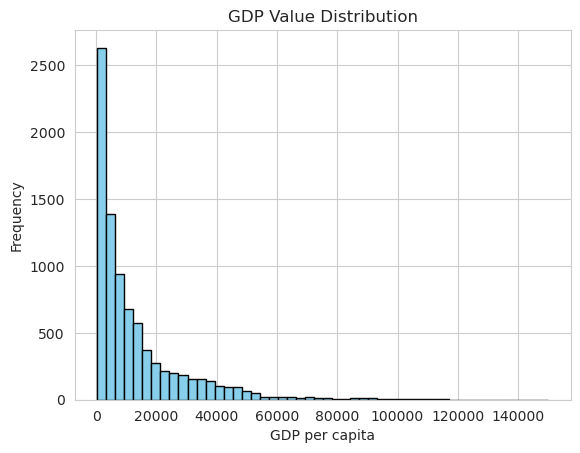

In [24]:
# Flatten the DataFrame to a 1D array, drop NaNs
gdp_values = gdp_filtered.values.flatten()
gdp_values = gdp_values[~np.isnan(gdp_values)]

# Print min, max, mean
print("Min GDP:", np.min(gdp_values))
print("Max GDP:", np.max(gdp_values))
print("Mean GDP:", np.mean(gdp_values))

# Plot value distribution
plt.hist(gdp_values, bins=50, color='skyblue', edgecolor='black')
plt.title("GDP Value Distribution")
plt.xlabel("GDP per capita")
plt.ylabel("Frequency")
plt.show()

Choosing a linear scale for GDP is not appropriate due to the wide range of values. A logarithmic scale is more suitable for visualizing GDP data, as it compresses the scale and allows for better comparison across countries with vastly different GDPs.